# Proyecto 2 - Modelo de Regresión Logística

## Configuración

**Librerías**

In [14]:
import pandas as pd
import numpy as np
from scipy.stats import uniform
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

**Parámetros**

In [2]:
base_de_datos = 'DB_LIMPIA.csv'

## Preprocesamiento

In [3]:
df = pd.read_csv(base_de_datos, sep = ";", index_col = 0)
df.columns

Index(['VIC_SEXO', 'VIC_EDAD', 'TOTAL_HIJOS', 'VIC_ESCOLARIDAD', 'VIC_EST_CIV',
       'VIC_GRUPET', 'VIC_TRABAJA', 'VIC_DISC', 'VIC_REL_AGR',
       'OTRAS_VICTIMAS', 'HEC_DIA', 'HEC_MES', 'HEC_ANO', 'HEC_AREA',
       'HEC_TIPAGRE', 'INST_DONDE_DENUNCIO', 'AGR_SEXO', 'AGR_EDAD',
       'AGR_ESCOLARIDAD', 'AGR_EST_CIV', 'AGR_GRUPET', 'AGR_TRABAJA',
       'INST_DENUN_HECHO', 'MEDIDAS_SEGURIDAD'],
      dtype='object')

In [4]:
# Se crea el DataFrame de víctimas.
df_victimas = df.loc[:, ['VIC_SEXO', 'VIC_EDAD', 'VIC_ESCOLARIDAD','VIC_EST_CIV', 'VIC_GRUPET', 'VIC_TRABAJA']]
df_victimas.columns = ['SEXO', 'EDAD', 'ESCOLARIDAD', 'ESTADO_CIVIL','GRUPO_ETNICO', 'TRABAJA']
df_victimas['ETIQUETA'] = 'VICTIMA'

# Se crea el DataFrame de agresores.
df_agresores = df.loc[:, ['AGR_SEXO', 'AGR_EDAD', 'AGR_ESCOLARIDAD','AGR_EST_CIV', 'AGR_GRUPET', 'AGR_TRABAJA']]
df_agresores.columns = ['SEXO', 'EDAD', 'ESCOLARIDAD', 'ESTADO_CIVIL','GRUPO_ETNICO', 'TRABAJA']
df_agresores['ETIQUETA'] = 'AGRESOR'

# Se crea el DataFrame de cluster.
df_classification = pd.concat([df_victimas, df_agresores])
df_classification.head(5)

,SEXO,EDAD,ESCOLARIDAD,ESTADO_CIVIL,GRUPO_ETNICO,TRABAJA,ETIQUETA
0,Mujeres,11,Primaria,Desconocido,Ladino,No,VICTIMA
1,Hombres,4,Desconocido,Desconocido,Ladino,Desconocido,VICTIMA
2,Hombres,11,Primaria,Desconocido,Ladino,No,VICTIMA
3,Mujeres,6,Desconocido,Desconocido,Ladino,Desconocido,VICTIMA
4,Hombres,11,Primaria,Desconocido,Ladino,No,VICTIMA


In [5]:
len(df_classification)

717996

In [6]:
counts = df_classification['ETIQUETA'].value_counts()
props  = df_classification['ETIQUETA'].value_counts(normalize=True) * 100

print("=== Distribución y proporción ===")
print(pd.DataFrame({'Cantidad': counts, 'Proporción (%)': props.round(2)}))

=== Distribución y proporción ===
          Cantidad  Proporción (%)
ETIQUETA                          
VICTIMA     358998            50.0
AGRESOR     358998            50.0


In [7]:
# Se seleccionan las columnas categóricas y numéricas.
cat_cols = ["SEXO", "ESCOLARIDAD", "ESTADO_CIVIL", "GRUPO_ETNICO", "TRABAJA"]
num_cols = ["EDAD"]

# Las columnas categóricas se transforman usando un OneHotEncoder.
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
df_classification_cat = ohe.fit_transform(df_classification[cat_cols])

# Se estandarizan las columnas numéricas.
scaler = StandardScaler()
df_classification_num = scaler.fit_transform(df_classification[num_cols])

# Se unen las variables transformadas en una matriz.
X = np.hstack([df_classification_num, df_classification_cat])

# Se crea el DataFrame ya con las variables transformadas.
feature_names = np.concatenate([num_cols, ohe.get_feature_names_out(cat_cols)])
df_classification_agg = pd.DataFrame(X, columns = feature_names, index = df_classification.index)
df_classification_agg['ETIQUETA'] = df_classification['ETIQUETA']
df_classification_agg.head()

,EDAD,SEXO_Hombres,SEXO_Mujeres,ESCOLARIDAD_Básico,ESCOLARIDAD_Desconocido,ESCOLARIDAD_Diversificado,ESCOLARIDAD_Ninguna,ESCOLARIDAD_Primaria,ESCOLARIDAD_Universidad,ESTADO_CIVIL_Casado,...,GRUPO_ETNICO_Desconocido,GRUPO_ETNICO_Garifuna,GRUPO_ETNICO_Ladino,GRUPO_ETNICO_Maya,GRUPO_ETNICO_Otro,GRUPO_ETNICO_Xinca,TRABAJA_Desconocido,TRABAJA_No,TRABAJA_Si,ETIQUETA
0,-1.585821,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,VICTIMA
1,-2.112327,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,VICTIMA
2,-1.585821,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,VICTIMA
3,-1.961897,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,VICTIMA
4,-1.585821,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,VICTIMA


## Elaboración del Modelo

In [8]:
# ── 1. Separar features y target ──────────────────────────────────────────────
X = df_classification_agg.drop(columns=['ETIQUETA'])
y = df_classification_agg['ETIQUETA']

# ── 2. Muestra estratificada del 25% para el RandomizedSearch ─────────────────
# stratify=y garantiza que la proporción 50/50 se mantenga en la muestra
X_sample, _, y_sample, _ = train_test_split(
    X, y,
    test_size=0.75,        # nos quedamos con el 25%
    stratify=y,
    random_state=42
)

# ── 3. Split del dataset COMPLETO para entrenar el modelo final ───────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,        # 80% train / 20% test
    stratify=y,
    random_state=42
)

print(f"Muestra para búsqueda:  {X_sample.shape[0]:,} registros")
print(f"Train (modelo final):   {X_train.shape[0]:,} registros")
print(f"Test  (evaluación):     {X_test.shape[0]:,} registros")

# Verificar que el balance se mantiene
print(f"\nBalance en muestra: {y_sample.value_counts(normalize=True).to_dict()}")
print(f"Balance en train:   {y_train.value_counts(normalize=True).to_dict()}")

Muestra para búsqueda:  179,499 registros
Train (modelo final):   574,396 registros
Test  (evaluación):     143,600 registros

Balance en muestra: {'VICTIMA': 0.5000027855308387, 'AGRESOR': 0.4999972144691614}
Balance en train:   {'VICTIMA': 0.5, 'AGRESOR': 0.5}


In [9]:
# ── 4. RandomizedSearch sobre la MUESTRA ─────────────────────────────────────
param_dist = {
    'C':            uniform(0.001, 10),
    'penalty':      ['l1', 'l2', 'elasticnet'],
    'solver':       ['saga'],
    'class_weight': ['balanced', None],
    'l1_ratio':     uniform(0, 1),      # solo aplica a elasticnet
    'max_iter':     [500, 1000, 2000]
}

search = RandomizedSearchCV(
    LogisticRegression(),
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_sample, y_sample)   # ← sobre la muestra

print("Mejores hiperparámetros:", search.best_params_)
print(f"Recall (CV muestra):    {search.best_score_:.4f}")

# ── 5. Entrenar modelo final con mejores hiperparámetros sobre TODO el train ──
best_model = LogisticRegression(**search.best_params_)
best_model.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\ajmac\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\ajmac\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ajmac\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
c:\Users\ajmac\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1

Mejores hiperparámetros: {'C': 3.746401188473625, 'class_weight': 'balanced', 'l1_ratio': 0.1834347898661638, 'max_iter': 500, 'penalty': 'l1', 'solver': 'saga'}
Recall (CV muestra):    nan


c:\Users\ajmac\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ajmac\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
c:\Users\ajmac\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.1834347898661638. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",3.746401188473625
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.1834347898661638
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class o

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Víctima       0.90      0.88      0.89    287198
     Agresor       0.88      0.90      0.89    287198

    accuracy                           0.89    574396
   macro avg       0.89      0.89      0.89    574396
weighted avg       0.89      0.89      0.89    574396



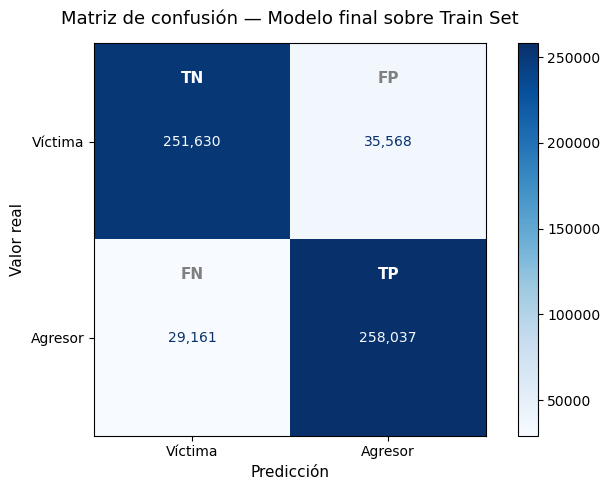


── Métricas clave ──────────────────────────────────────
  Recall (sensibilidad):  0.8762
  Precisión:              0.8961
  F1-Score:               0.8860
  Accuracy:               0.8873
  Falsos negativos (FN):  29,161  ← agresores clasificados como víctimas
  Falsos positivos (FP):  35,568  ← víctimas clasificadas como agresores


In [16]:
# ── 6.a Predicciones sobre el train set ────────────────────────────────────────
y_pred_train = best_model.predict(X_train)

# ── 7.a Classification Report ──────────────────────────────────────────────────
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_train, y_pred_train, target_names=['Víctima', 'Agresor']))

# ── 8.a Matriz de confusión ────────────────────────────────────────────────────
cm_train = confusion_matrix(y_train, y_pred_train)

fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=['Víctima', 'Agresor']
)
disp.plot(ax=ax, cmap='Blues', values_format=',.0f')

# Anotaciones de TP / TN / FP / FN
labels = [
    ('TN', 0, 0), ('FP', 0, 1),
    ('FN', 1, 0), ('TP', 1, 1)
]
for name, row, col in labels:
    ax.text(
        col, row - 0.32,
        name,
        ha='center', va='center',
        fontsize=11, fontweight='bold',
        color='white' if name in ('TP', 'TN') else 'gray'
    )

ax.set_title('Matriz de confusión — Modelo final sobre Train Set', fontsize=13, pad=14)
ax.set_xlabel('Predicción', fontsize=11)
ax.set_ylabel('Valor real', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix_train.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9.a Métricas clave resumidas ───────────────────────────────────────────────
tn, fp, fn, tp = cm_train.ravel()

print("\n── Métricas clave ──────────────────────────────────────")
print(f"  Recall (sensibilidad):  {recall_score(y_train, y_pred_train, pos_label='AGRESOR'):.4f}")
print(f"  Precisión:              {precision_score(y_train, y_pred_train, pos_label='AGRESOR'):.4f}")
print(f"  F1-Score:               {f1_score(y_train, y_pred_train, pos_label='AGRESOR'):.4f}")
print(f"  Accuracy:               {accuracy_score(y_train, y_pred_train):.4f}")
print(f"  Falsos negativos (FN):  {fn:,}  ← agresores clasificados como víctimas")
print(f"  Falsos positivos (FP):  {fp:,}  ← víctimas clasificadas como agresores")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Víctima       0.90      0.88      0.89     71800
     Agresor       0.88      0.90      0.89     71800

    accuracy                           0.89    143600
   macro avg       0.89      0.89      0.89    143600
weighted avg       0.89      0.89      0.89    143600



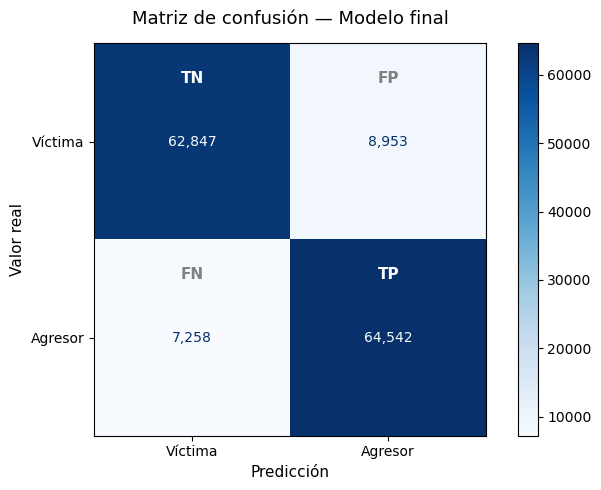


── Métricas clave ──────────────────────────────────────
  Recall (sensibilidad):  0.8753
  Precisión:              0.8965
  F1-Score:               0.8858
  Accuracy:               0.8871
  Falsos negativos (FN):  7,258  ← agresores clasificados como víctimas
  Falsos positivos (FP):  8,953  ← víctimas clasificadas como agresores


In [18]:
# ── 6.b Predicciones sobre el test set ────────────────────────────────────────
y_pred = best_model.predict(X_test)

# ── 7.b Classification Report ──────────────────────────────────────────────────
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Víctima', 'Agresor']))

# ── 8.b Matriz de confusión ────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Víctima', 'Agresor']
)
disp.plot(ax=ax, cmap='Blues', values_format=',.0f')

# Anotaciones de TP / TN / FP / FN
labels = [
    ('TN', 0, 0), ('FP', 0, 1),
    ('FN', 1, 0), ('TP', 1, 1)
]
for name, row, col in labels:
    ax.text(
        col, row - 0.32,
        name,
        ha='center', va='center',
        fontsize=11, fontweight='bold',
        color='white' if name in ('TP', 'TN') else 'gray'
    )

ax.set_title('Matriz de confusión — Modelo final', fontsize=13, pad=14)
ax.set_xlabel('Predicción', fontsize=11)
ax.set_ylabel('Valor real', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9.b Métricas clave resumidas ───────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()

print("\n── Métricas clave ──────────────────────────────────────")
print(f"  Recall (sensibilidad):  {recall_score(y_test, y_pred, pos_label='AGRESOR'):.4f}")
print(f"  Precisión:              {precision_score(y_test, y_pred, pos_label='AGRESOR'):.4f}")
print(f"  F1-Score:               {f1_score(y_test, y_pred, pos_label='AGRESOR'):.4f}")
print(f"  Accuracy:               {accuracy_score(y_test, y_pred):.4f}")
print(f"  Falsos negativos (FN):  {fn:,}  ← agresores clasificados como víctimas")
print(f"  Falsos positivos (FP):  {fp:,}  ← víctimas clasificadas como agresores")

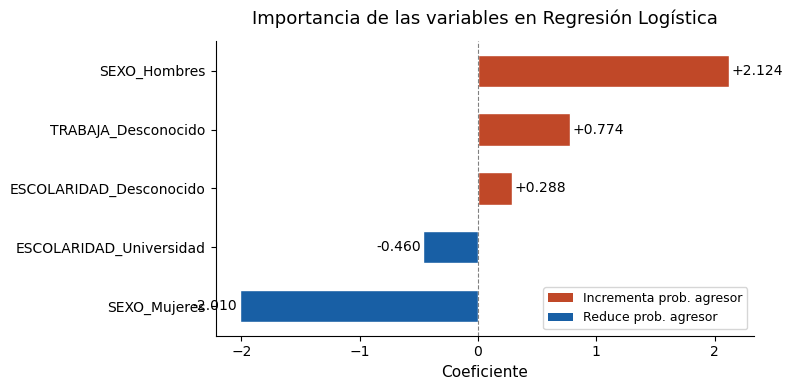

In [22]:
# ── 10. Top 5 variables por peso (coeficiente absoluto) ──────────────────────
feature_names = X.columns.tolist()
coefs = best_model.coef_[0]

importance_df = (
    pd.DataFrame({'variable': feature_names, 'coeficiente': coefs})
    .assign(
        coeficiente=lambda d: -d['coeficiente'],   # ← invertir signo
        peso_abs=lambda d: d['coeficiente'].abs()
    )
    .sort_values('peso_abs', ascending=False)
    .head(5)
    .sort_values('coeficiente')
)

# ── 11. Gráfica ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#C04828' if c > 0 else '#185FA5' for c in importance_df['coeficiente']]

bars = ax.barh(
    importance_df['variable'],
    importance_df['coeficiente'],
    color=colors,
    edgecolor='white',
    height=0.55
)

# Etiquetas de valor al lado de cada barra
for bar, val in zip(bars, importance_df['coeficiente']):
    offset = 0.01 * (importance_df['coeficiente'].abs().max())
    ha = 'left' if val >= 0 else 'right'
    x  = val + offset if val >= 0 else val - offset
    ax.text(x, bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=10)

ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coeficiente', fontsize=11)
ax.set_title('Importancia de las variables en Regresión Logística', fontsize=13, pad=12)
ax.spines[['top', 'right']].set_visible(False)

# Leyenda de color
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C04828', label='Incrementa prob. agresor'),
    Patch(facecolor='#185FA5', label='Reduce prob. agresor'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('top5_features.png', dpi=150, bbox_inches='tight')
plt.show()